In [1]:
import numpy as np
import pandas as pd
import ast

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
movies = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/projectes/recommend System/tmdb_5000_movies.csv")
credits = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/projectes/recommend System/tmdb_5000_credits.csv")

In [4]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


In [5]:
credits.head(1)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [6]:
movies = movies.merge(credits ,on='title')

In [7]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [8]:
# genres, 	keywords, id, title, overview, cast, crew

movies = movies[["id","title","genres", "keywords",   "overview", "cast", "crew"]]

In [9]:
movies.head(1)


,id,title,genres,keywords,overview,cast,crew
0,19995,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","In the 22nd century, a paraplegic Marine is di...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [10]:
movies.isnull().sum()

,0
id,0
title,0
genres,0
keywords,0
overview,3
cast,0
crew,0


In [11]:
movies.dropna(inplace=True)

In [12]:
movies.duplicated().sum()

np.int64(0)

In [13]:
movies.iloc[0].genres

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [14]:
def convert(obj):
  l=[]
  for i in ast.literal_eval(obj):
    l.append(i['name'])
  return l

In [15]:
movies['genres'] = movies['genres'].apply(convert)

In [16]:
movies.head(1)

,id,title,genres,keywords,overview,cast,crew
0,19995,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","In the 22nd century, a paraplegic Marine is di...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [17]:
movies['keywords'] = movies['keywords'].apply(convert)

In [18]:
import ast

def convert4(obj):
    l = []
    counter = 0
    try:
        data = ast.literal_eval(obj)
        for i in data:
            if counter != 3:
                l.append(i['name'])
                counter += 1
            else:
                break
    except (ValueError, SyntaxError, TypeError):
        pass
    return l


In [19]:
movies['cast'] = movies['cast'].apply(convert4)

In [20]:
movies.head(1)

,id,title,genres,keywords,overview,cast,crew
0,19995,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","In the 22nd century, a paraplegic Marine is di...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [21]:
def fatch_dir(obj):
  l=[]
  for i in ast.literal_eval(obj):
    if i['job'] == 'Director':
      l.append(i['name'])
      break
  return l

In [22]:
movies['crew'] = movies['crew'].apply(fatch_dir)

In [23]:
movies['overview'] = movies['overview'].apply(lambda x:x.split())

In [24]:
movies.head(1)

,id,title,genres,keywords,overview,cast,crew
0,19995,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[In, the, 22nd, century,, a, paraplegic, Marin...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]


In [25]:
movies['genres'] = movies['genres'].apply(lambda x:[i.replace(" ","") for i in x])
movies['keywords'] = movies['keywords'].apply(lambda x:[i.replace(" ","") for i in x])
movies['cast'] = movies['cast'].apply(lambda x:[i.replace(" ","") for i in x])
movies['crew'] = movies['crew'].apply(lambda x:[i.replace(" ","") for i in x])

In [26]:
movies.head()

,id,title,genres,keywords,overview,cast,crew
0,19995,Avatar,"[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[In, the, 22nd, century,, a, paraplegic, Marin...","[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron]
1,285,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[Captain, Barbossa,, long, believed, to, be, d...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski]
2,206647,Spectre,"[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[A, cryptic, message, from, Bond’s, past, send...","[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes]
3,49026,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...","[Following, the, death, of, District, Attorney...","[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan]
4,49529,John Carter,"[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","[John, Carter, is, a, war-weary,, former, mili...","[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton]


In [27]:
movies['tags'] = movies['genres'] + movies['cast'] + movies['crew'] + movies['keywords'] + movies['overview']

In [28]:
movies.head()

,id,title,genres,keywords,overview,cast,crew,tags
0,19995,Avatar,"[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[In, the, 22nd, century,, a, paraplegic, Marin...","[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron],"[Action, Adventure, Fantasy, ScienceFiction, S..."
1,285,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[Captain, Barbossa,, long, believed, to, be, d...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski],"[Adventure, Fantasy, Action, JohnnyDepp, Orlan..."
2,206647,Spectre,"[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[A, cryptic, message, from, Bond’s, past, send...","[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes],"[Action, Adventure, Crime, DanielCraig, Christ..."
3,49026,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...","[Following, the, death, of, District, Attorney...","[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan],"[Action, Crime, Drama, Thriller, ChristianBale..."
4,49529,John Carter,"[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","[John, Carter, is, a, war-weary,, former, mili...","[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton],"[Action, Adventure, ScienceFiction, TaylorKits..."


In [29]:
new_df= movies[['id', 'title', 'tags']]

In [30]:
new_df.head()

,id,title,tags
0,19995,Avatar,"[Action, Adventure, Fantasy, ScienceFiction, S..."
1,285,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action, JohnnyDepp, Orlan..."
2,206647,Spectre,"[Action, Adventure, Crime, DanielCraig, Christ..."
3,49026,The Dark Knight Rises,"[Action, Crime, Drama, Thriller, ChristianBale..."
4,49529,John Carter,"[Action, Adventure, ScienceFiction, TaylorKits..."


In [31]:
new_df['tags'] = new_df['tags'].apply(lambda x:" ".join(x))

/tmp/ipython-input-3089450492.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(lambda x:" ".join(x))


In [32]:
new_df

,id,title,tags
0,19995,Avatar,Action Adventure Fantasy ScienceFiction SamWor...
1,285,Pirates of the Caribbean: At World's End,Adventure Fantasy Action JohnnyDepp OrlandoBlo...
2,206647,Spectre,Action Adventure Crime DanielCraig ChristophWa...
3,49026,The Dark Knight Rises,Action Crime Drama Thriller ChristianBale Mich...
4,49529,John Carter,Action Adventure ScienceFiction TaylorKitsch L...
...,...,...,...
4804,9367,El Mariachi,Action Crime Thriller CarlosGallardo JaimedeHo...
4805,72766,Newlyweds,Comedy Romance EdwardBurns KerryBishé MarshaDi...
4806,231617,"Signed, Sealed, Delivered",Comedy Drama Romance TVMovie EricMabius Kristi...
4807,126186,Shanghai Calling,DanielHenney ElizaCoupe BillPaxton DanielHsia ...


In [33]:
import nltk
from nltk.stem.porter import PorterStemmer
ps= PorterStemmer()

In [34]:
def stem(text):
  y=[]
  for i in text.split():
    y.append(ps.stem(i))
  return " ".join(y)


In [35]:
new_df['tags'] = new_df['tags'].apply(stem)

/tmp/ipython-input-3213734980.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(stem)


In [36]:
new_df['tags'] = new_df['tags'].apply(lambda x:x.lower())

/tmp/ipython-input-3214958533.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(lambda x:x.lower())


In [37]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000, stop_words="english")

In [38]:
vector = cv.fit_transform(new_df['tags']).toarray()

In [39]:
from sklearn.metrics.pairwise import cosine_similarity

In [40]:
similarity = cosine_similarity(vector)

In [41]:
sorted(list(enumerate(similarity[0])),reverse=True, key=lambda x:x[1])[1:6]

[(1214, np.float64(0.28676966733820225)),
 (2405, np.float64(0.26901379342448517)),
 (3728, np.float64(0.2605130246476754)),
 (507, np.float64(0.255608593705383)),
 (539, np.float64(0.25038669783359574))]

In [42]:
def recommend(movie):
  movie_index = new_df[new_df['title']== movie].index[0]
  distance = similarity[movie_index]
  movie_list = sorted(list(enumerate(distance)),reverse=True, key=lambda x:x[1])[1:6]
  for i in movie_list:
    print(new_df.iloc[i[0]].title)


# **Enter the movie name for recommend**

In [43]:
recommend("Spectre")

Quantum of Solace
Skyfall
Never Say Never Again
From Russia with Love
Octopussy


1.34

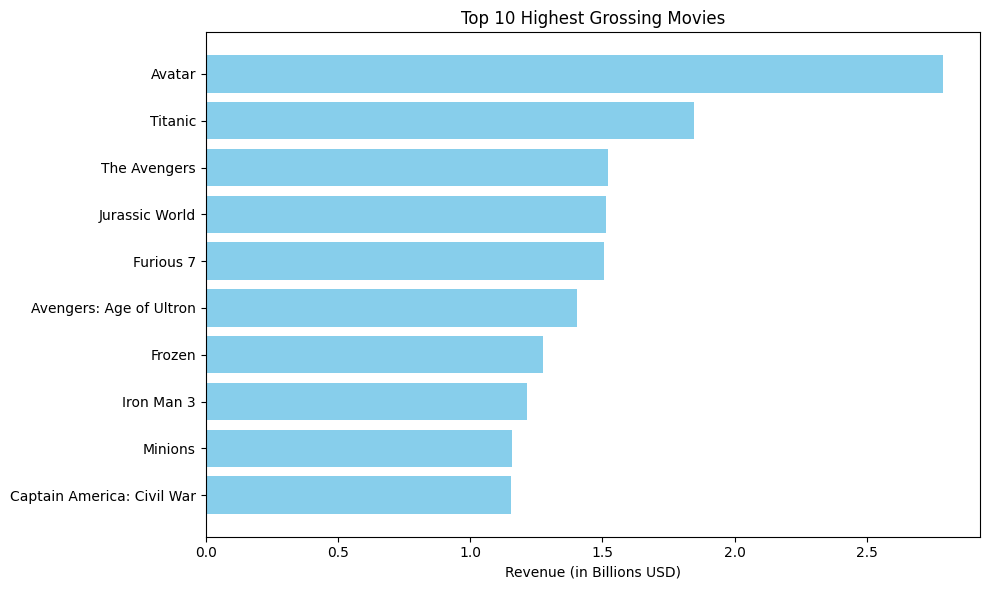

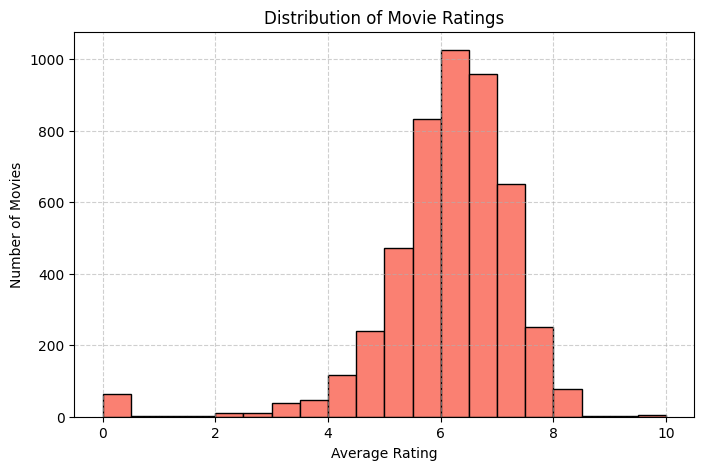

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
movies3 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/projectes/recommend System/tmdb_5000_movies.csv")
credits3 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/projectes/recommend System/tmdb_5000_credits.csv")

# --- 1. Top 10 Highest Grossing Movies ---
top_revenue = movies3.sort_values(by='revenue', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_revenue['title'], top_revenue['revenue']/1e9, color='skyblue')
plt.xlabel('Revenue (in Billions USD)')
plt.title('Top 10 Highest Grossing Movies')
plt.gca().invert_yaxis()  # Highest at the top
plt.tight_layout()
plt.show()

# --- 3. Distribution of Movie Ratings ---
plt.figure(figsize=(8,5))
plt.hist(movies3['vote_average'], bins=20, color='salmon', edgecolor='black')
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.title('Distribution of Movie Ratings')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
